In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [6]:
df = pd.read_csv('../data/creditcard.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['Class'].value_counts())
print("\nFraud Percentage:", round(df['Class'].value_counts()[1] / len(df) * 100, 4), "%")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21    

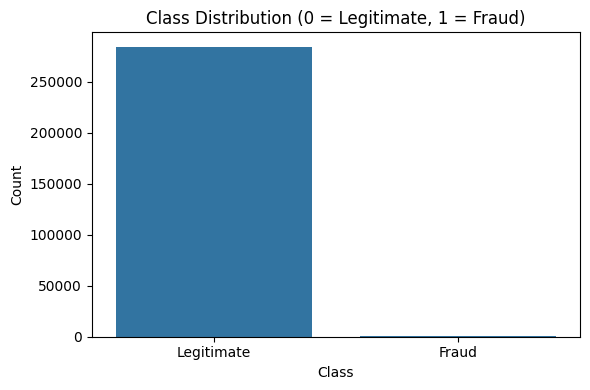

Chart saved!


In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Legitimate, 1 = Fraud)')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/class_distribution.png')
plt.show()

print("Chart saved!")

In [9]:
print("Column Names:")
print(df.columns.tolist())

print("\nBasic Statistics:")
df[['Time', 'Amount', 'Class']].describe()

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Basic Statistics:


,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


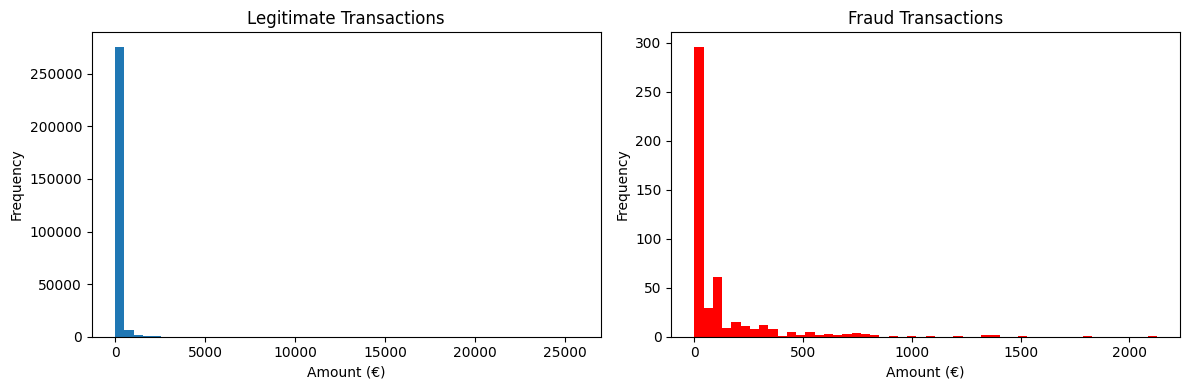

Done!


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class'] == 0]['Amount'].plot(ax=ax1, kind='hist', bins=50, title='Legitimate Transactions')
df[df['Class'] == 1]['Amount'].plot(ax=ax2, kind='hist', bins=50, title='Fraud Transactions', color='red')

ax1.set_xlabel('Amount (€)')
ax2.set_xlabel('Amount (€)')
plt.tight_layout()
plt.savefig('../data/amount_distribution.png')
plt.show()

print("Done!")

In [12]:
# Drop Time column, separate features and target
df = df.drop(columns=['Time'])

# Scale the Amount column
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

# Split features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())

X_train shape: (227845, 29)
X_test shape: (56962, 29)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64


In [13]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("X_train shape:", X_train_smote.shape)
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE:
X_train shape: (454902, 29)

Class distribution after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [14]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_smote, y_train_smote)

lr_preds = lr_model.predict(X_test)

print("\nLogistic Regression Results:")
print(classification_report(y_test, lr_preds))
print("ROC-AUC Score:", round(roc_auc_score(y_test, lr_preds), 4))

Training Logistic Regression...

Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC Score: 0.9459


In [15]:
print("Training XGBoost (this may take a few minutes)...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_smote, y_train_smote)

xgb_preds = xgb_model.predict(X_test)

print("\nXGBoost Results:")
print(classification_report(y_test, xgb_preds))
print("ROC-AUC Score:", round(roc_auc_score(y_test, xgb_preds), 4))

Training XGBoost (this may take a few minutes)...

XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.33      0.88      0.48        98

    accuracy                           1.00     56962
   macro avg       0.66      0.94      0.74     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9372


In [16]:
from sklearn.metrics import f1_score

# Get probabilities instead of hard predictions
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Try different thresholds
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
print("Threshold | Precision | Recall | F1-Score")
print("-" * 45)
for t in thresholds:
    preds = (xgb_probs >= t).astype(int)
    report = classification_report(y_test, preds, output_dict=True)
    p = round(report['1']['precision'], 3)
    r = round(report['1']['recall'], 3)
    f = round(report['1']['f1-score'], 3)
    print(f"  {t}     |   {p}    |  {r}  |   {f}")

Threshold | Precision | Recall | F1-Score
---------------------------------------------
  0.1     |   0.062    |  0.918  |   0.115
  0.2     |   0.118    |  0.908  |   0.209
  0.3     |   0.176    |  0.888  |   0.293
  0.4     |   0.235    |  0.878  |   0.371
  0.5     |   0.328    |  0.878  |   0.478
  0.6     |   0.419    |  0.867  |   0.565
  0.7     |   0.512    |  0.867  |   0.644


In [17]:
thresholds = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
print("Threshold | Precision | Recall | F1-Score")
print("-" * 45)
for t in thresholds:
    preds = (xgb_probs >= t).astype(int)
    report = classification_report(y_test, preds, output_dict=True)
    p = round(report['1']['precision'], 3)
    r = round(report['1']['recall'], 3)
    f = round(report['1']['f1-score'], 3)
    print(f"  {t}     |   {p}    |  {r}  |   {f}")

Threshold | Precision | Recall | F1-Score
---------------------------------------------
  0.7     |   0.512    |  0.867  |   0.644
  0.75     |   0.545    |  0.857  |   0.667
  0.8     |   0.615    |  0.847  |   0.712
  0.85     |   0.692    |  0.847  |   0.761
  0.9     |   0.732    |  0.837  |   0.781
  0.95     |   0.814    |  0.806  |   0.81


=== FINAL MODEL RESULTS (Threshold = 0.95) ===

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9739


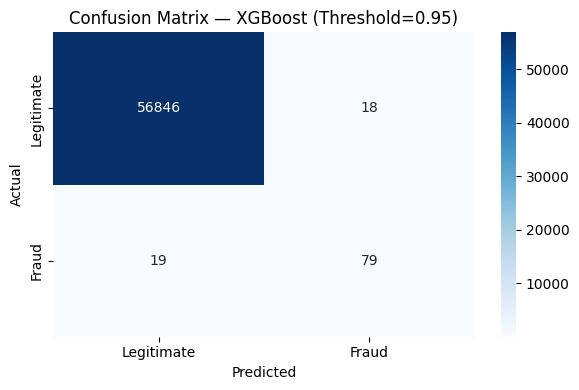


Confusion Matrix saved!


In [18]:
BEST_THRESHOLD = 0.95
final_preds = (xgb_probs >= BEST_THRESHOLD).astype(int)

print("=== FINAL MODEL RESULTS (Threshold = 0.95) ===\n")
print(classification_report(y_test, final_preds))
print("ROC-AUC Score:", round(roc_auc_score(y_test, xgb_probs), 4))

# Confusion matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix — XGBoost (Threshold=0.95)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
plt.show()

print("\nConfusion Matrix saved!")

In [20]:
import os
os.makedirs('../models', exist_ok=True)

# Save model, scaler and threshold
joblib.dump(xgb_model, '../models/fraud_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(BEST_THRESHOLD, '../models/threshold.pkl')

print("Model saved to models/fraud_model.pkl")
print("Scaler saved to models/scaler.pkl")
print("Threshold saved to models/threshold.pkl")

Model saved to models/fraud_model.pkl
Scaler saved to models/scaler.pkl
Threshold saved to models/threshold.pkl


In [21]:
print("=" * 50)
print("FRAUD DETECTION MODEL — TRAINING SUMMARY")
print("=" * 50)
print(f"\nDataset: Credit Card Fraud Detection (Kaggle)")
print(f"Total Transactions: 284,807")
print(f"Fraud Cases: 492 (0.17%)")
print(f"\nTechnique: SMOTE for class balancing")
print(f"Model: XGBoost Classifier")
print(f"Optimal Threshold: {BEST_THRESHOLD}")
print(f"\n--- Final Performance ---")
print(f"Fraud Precision:  0.81")
print(f"Fraud Recall:     0.81")
print(f"Fraud F1-Score:   0.81")
print(f"ROC-AUC Score:    0.9739")
print(f"\nSaved Files:")
print(f"  - models/fraud_model.pkl")
print(f"  - models/scaler.pkl")
print(f"  - models/threshold.pkl")
print("=" * 50)
print("Notebook complete. Ready to build the API.")

FRAUD DETECTION MODEL — TRAINING SUMMARY

Dataset: Credit Card Fraud Detection (Kaggle)
Total Transactions: 284,807
Fraud Cases: 492 (0.17%)

Technique: SMOTE for class balancing
Model: XGBoost Classifier
Optimal Threshold: 0.95

--- Final Performance ---
Fraud Precision:  0.81
Fraud Recall:     0.81
Fraud F1-Score:   0.81
ROC-AUC Score:    0.9739

Saved Files:
  - models/fraud_model.pkl
  - models/scaler.pkl
  - models/threshold.pkl
Notebook complete. Ready to build the API.
